In [ ]:

import os
import sys

from focal_loss import BinaryFocalLoss
import os
import sys
import argparse
import numpy as np
from tensorflow.keras.models import model_from_json
import numpy as np
import tensorflow.keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, LSTM
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Conv1D, MaxPooling1D,AveragePooling1D
from tensorflow.keras.optimizers import SGD
#from tensorflow.keras.layers.wrappers import Bidirectional, TimeDistributed
from tensorflow.keras import regularizers
from tensorflow.keras import optimizers
from tensorflow.keras.layers import Input, BatchNormalization
from tensorflow.keras.models import Model
from sklearn import metrics
import tensorflow as tf
from tensorflow.keras import regularizers
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_recall_curve
from tensorflow.keras import initializers
from tensorflow.keras.layers import Activation, Dense, Add
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
import pandas as pd
import os
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import learning_curve
from sklearn import metrics
from sklearn.metrics import auc
from tensorflow.keras.layers import LSTM
from focal_loss import BinaryFocalLoss
from Bio import SeqIO
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from sklearn.model_selection import StratifiedKFold


#CNN Model
def get_model():

	input_shape = (81,4)
	inputs = Input(shape = input_shape)

	convLayer = Conv1D(filters = 32, kernel_size = 7,activation = 'relu',input_shape = input_shape, kernel_regularizer = regularizers.l2(1e-5), bias_regularizer = regularizers.l2(1e-4))(inputs)
	normalizationLayer = BatchNormalization()(convLayer);
	poolingLayer = AveragePooling1D(pool_size = 2, strides=2)(normalizationLayer)
	dropoutLayer0 = Dropout(0.35)(normalizationLayer)

	convLayer2 = Conv1D(filters = 32, kernel_size = 5,activation = 'relu',kernel_regularizer = regularizers.l2(1e-4), bias_regularizer = regularizers.l2(1e-5))(dropoutLayer0)
	poolingLayer2 = MaxPooling1D(pool_size = 2, strides=2)(convLayer2)
	dropoutLayer1 = Dropout(0.30)(poolingLayer2)

	flattenLayer = Flatten()(dropoutLayer1)

	denseLayer = Dense(16, activation = 'relu',kernel_regularizer = regularizers.l2(1e-3),bias_regularizer = regularizers.l2(1e-3))(flattenLayer)
	outLayer = Dense(1, activation='sigmoid')(denseLayer)

	model = Model(inputs = inputs, outputs = outLayer)
	model.compile(
    loss='binary_crossentropy',
    optimizer=SGD(learning_rate=0.007, momentum=0.95),
    metrics=['binary_accuracy']
    )


	return model

#Download all model
modelProMN = get_model()
modelProMN.load_weights('best_weights_Pro_NonPro.h5')
modelSigma70=get_model()
modelSigma70.load_weights('best_weights_Sigma70.h5')
modelSigma24=get_model()
modelSigma24.load_weights('best_weights_Sigma24_v1.h5')
modelSigma28=get_model()
modelSigma28.load_weights('best_weights_Sigma28.h5')
modelSigma38=get_model()
modelSigma38.load_weights('best_weights_Sigma38.h5')
modelSigma32=get_model()
modelSigma32.load_weights('best_weights_Sigma32.h5')
import numpy as np

#OneHote Encoding
def encode_seq(s):
    Encode = {
        'A':[1,0,0,0],
        'T':[0,1,0,0],
        'C':[0,0,1,0],
        'G':[0,0,0,1],
        'N':[0,0,0,0]
    }

    return np.array([Encode.get(x.upper(), [0,0,0,0]) for x in s])


X1 = {}
accumulator=0


#Read Sequence file in fasta format using BioPython liberary
sequences=[]
sequences = []
for record in SeqIO.parse("output.fasta", "fasta"):
    s = str(record.seq)   # ✅ always give clean string
    sequences.append(s)


Strng="TTCAGTGATAATTATCACATTTCAATTGCACATTAATGGATATTCTTTAATAATCTCGCGACGTTTCTTTATGATAAATAA"

#Fucation to pass a Sequence
def pcPromoter(Strng):
    my_hottie = encode_seq(Strng)
    out_final = np.array(my_hottie)

    # Reshape to match model input shape (1, 81, 4)
    out_final = out_final.reshape(1, -1, 4)

    pr = modelProMN.predict(out_final)
    pr=pr.round()
    if(pr==1):
        print('\n promoter \n')
        prS70=modelSigma70.predict(out_final)
        prS70=prS70.round()
        if(prS70==1):
            print('\n sigma70 \n')

        else:
            pr24=modelSigma24.predict(out_final)
            pr24=pr24.round()
            if(pr24==1):
                print('\n sigma24 \n')

            else:
                pr28=modelSigma28.predict(out_final)
                pr28=pr28.round()
                if(pr28==1):
                    print('\n Sigma28 \n')

                else:
                    pr38=modelSigma38.predict(out_final)
                    pr38=pr38.round()
                    if(pr38==1):
                        print('\n Sigma38 \n')

                    else:
                        pr32=modelSigma32.predict(out_final)
                        pr32=pr32.round()
                        if(pr32==1):
                            print('\n Sigma32 \n')

                        else:
                            print('\n Sigma 54 \n')



    else:
        print('non promoter')



#pass all sequences togather

for i in range(len(sequences)):
    pcPromoter(sequences[i])





1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step

 promoter 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step

 sigma24 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step

 promoter 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step

 sigma24 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
non promoter
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step

 promoter 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step

 sigma24 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step

 promoter 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step

 sigma24 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step

 promoter 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step

 sigma24 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step

 promoter 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step

 sigma24 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step

 promoter 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━

In [ ]:
true_labels = []
predicted_labels = []


In [ ]:
from Bio import SeqIO

sequences = []
true_labels = []

for record in SeqIO.parse("output.fasta", "fasta"):
    seq = str(record.seq)
    header = record.description

    # Extract true label from header
    if "SIGMA24" in header.upper():
        label = "SIGMA24"
    elif "SIGMA70" in header.upper():
        label = "SIGMA70"
    elif "SIGMA28" in header.upper():
        label = "SIGMA28"
    elif "SIGMA38" in header.upper():
        label = "SIGMA38"
    elif "SIGMA32" in header.upper():
        label = "SIGMA32"
    elif "PROMOTER" in header.upper():
        label = "PROMOTER"
    else:
        label = "NON_PROMOTER"

    sequences.append(seq)
    true_labels.append(label)



In [ ]:
def pcPromoter_predict(Strng):
    my_hottie = encode_seq(Strng)
    out_final = np.array(my_hottie).reshape(1, -1, 4)

    pr = modelProMN.predict(out_final, verbose=0).round()

    if pr == 0:
        return "NON_PROMOTER"

    if modelSigma70.predict(out_final, verbose=0).round() == 1:
        return "SIGMA70"
    elif modelSigma24.predict(out_final, verbose=0).round() == 1:
        return "SIGMA24"
    elif modelSigma28.predict(out_final, verbose=0).round() == 1:
        return "SIGMA28"
    elif modelSigma38.predict(out_final, verbose=0).round() == 1:
        return "SIGMA38"
    elif modelSigma32.predict(out_final, verbose=0).round() == 1:
        return "SIGMA32"
    else:
        return "SIGMA54"


In [ ]:
predicted_labels = []

for seq in sequences:
    pred = pcPromoter_predict(seq)
    predicted_labels.append(pred)


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Accuracy:", accuracy_score(true_labels, predicted_labels))

print("\nConfusion Matrix:")
print(confusion_matrix(true_labels, predicted_labels))

print("\nClassification Report:")
print(classification_report(true_labels, predicted_labels))


Accuracy: 0.7288943053401286

Confusion Matrix:
[[4617    0  253   42   55   80  207  890]
 [  65    0    5    3    0    1    5   29]
 [  16    0  401    0    0    2   52   15]
 [   7    0    6   81    0    4   11   21]
 [  24    0   50   12   67   49   13   70]
 [  16    0    3    0    0    6    8  131]
 [   0    0    0    0    0    0    0    0]
 [ 229    0    4    2    5   16   46 1407]]

Classification Report:
              precision    recall  f1-score   support

NON_PROMOTER       0.93      0.75      0.83      6144
    PROMOTER       0.00      0.00      0.00       108
     SIGMA24       0.56      0.83      0.66       486
     SIGMA28       0.58      0.62      0.60       130
     SIGMA32       0.53      0.24      0.33       285
     SIGMA38       0.04      0.04      0.04       164
     SIGMA54       0.00      0.00      0.00         0
     SIGMA70       0.55      0.82      0.66      1709

    accuracy                           0.73      9026
   macro avg       0.40      0.41      0.

c:\Users\Mohsin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Mohsin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Mohsin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Mohsin\anaconda3\Lib\site-packages\s

Matthews Correlation Coefficient (MCC): 0.5882511035999359


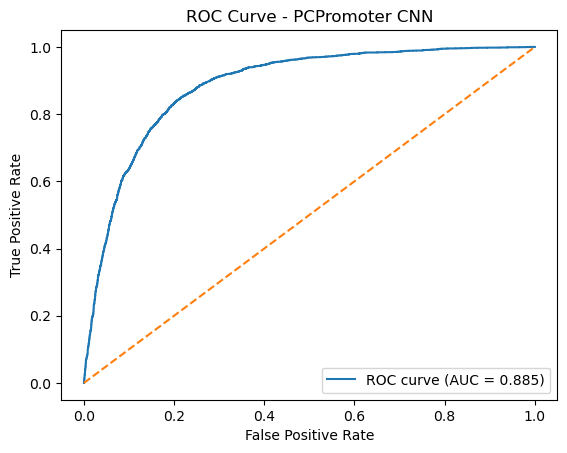

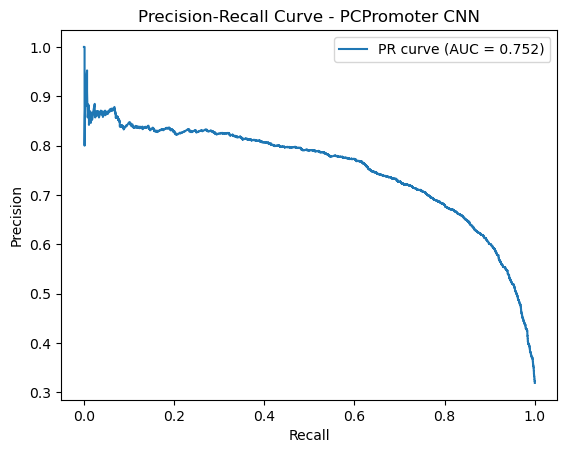

In [ ]:
from sklearn.metrics import matthews_corrcoef, roc_curve, auc, precision_recall_curve
import matplotlib.pyplot as plt
import numpy as np

# ---------- Convert labels to binary (Promoter vs Non-Promoter) ----------
y_true_binary = [1 if lbl != "NON_PROMOTER" else 0 for lbl in true_labels]
y_pred_binary = [1 if lbl != "NON_PROMOTER" else 0 for lbl in predicted_labels]

# ---------- MCC ----------
mcc = matthews_corrcoef(y_true_binary, y_pred_binary)
print("Matthews Correlation Coefficient (MCC):", mcc)

# ---------- Get probability scores ----------
# If your model does not return probability, we re-predict properly
y_scores = []

for seq in sequences:
    encoded = encode_seq(seq).reshape(1, -1, 4)
    prob = modelProMN.predict(encoded, verbose=0)[0][0]
    y_scores.append(prob)

y_scores = np.array(y_scores)

# ---------- ROC Curve ----------
fpr, tpr, _ = roc_curve(y_true_binary, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label='ROC curve (AUC = %0.3f)' % roc_auc)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - PCPromoter CNN')
plt.legend()
plt.show()

# ---------- Precision-Recall Curve ----------
precision, recall, _ = precision_recall_curve(y_true_binary, y_scores)
pr_auc = auc(recall, precision)

plt.figure()
plt.plot(recall, precision, label='PR curve (AUC = %0.3f)' % pr_auc)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - PCPromoter CNN')
plt.legend()
plt.show()


In [ ]:
from sklearn.metrics import confusion_matrix, matthews_corrcoef
import numpy as np

# List of sigma types including NON_PROMOTER
classes = ["SIGMA24", "SIGMA28", "SIGMA32", "SIGMA38", "SIGMA70", "SIGMA54", "NON_PROMOTER"]

# Convert lists to numpy arrays for easy indexing
y_true = np.array(true_labels)
y_pred = np.array(predicted_labels)

print(f"{'Class':<10} {'Accuracy':<10} {'Sensitivity':<12} {'Specificity':<12} {'MCC':<10}")
print("-"*60)

for cls in classes:
    # Binary representation for this class
    y_true_binary = np.array([1 if lbl == cls else 0 for lbl in y_true])
    y_pred_binary = np.array([1 if lbl == cls else 0 for lbl in y_pred])

    # Confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_true_binary, y_pred_binary, labels=[0,1]).ravel()

    # Metrics
    accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp+tn+fp+fn)!=0 else 0
    sensitivity = tp / (tp + fn) if (tp + fn)!=0 else 0
    specificity = tn / (tn + fp) if (tn + fp)!=0 else 0
    mcc = matthews_corrcoef(y_true_binary, y_pred_binary) if (tp+tn+fp+fn)!=0 else 0

    print(f"{cls:<10} {accuracy:<10.3f} {sensitivity:<12.3f} {specificity:<12.3f} {mcc:<10.3f}")


Class      Accuracy   Sensitivity  Specificity  MCC       
------------------------------------------------------------
SIGMA24    0.955      0.825        0.962        0.655     
SIGMA28    0.988      0.623        0.993        0.594     
SIGMA32    0.969      0.235        0.993        0.339     
SIGMA38    0.966      0.037        0.983        0.020     
SIGMA70    0.838      0.823        0.842        0.578     
SIGMA54    0.962      0.000        0.962        0.000     
NON_PROMOTER 0.791      0.751        0.876        0.588     


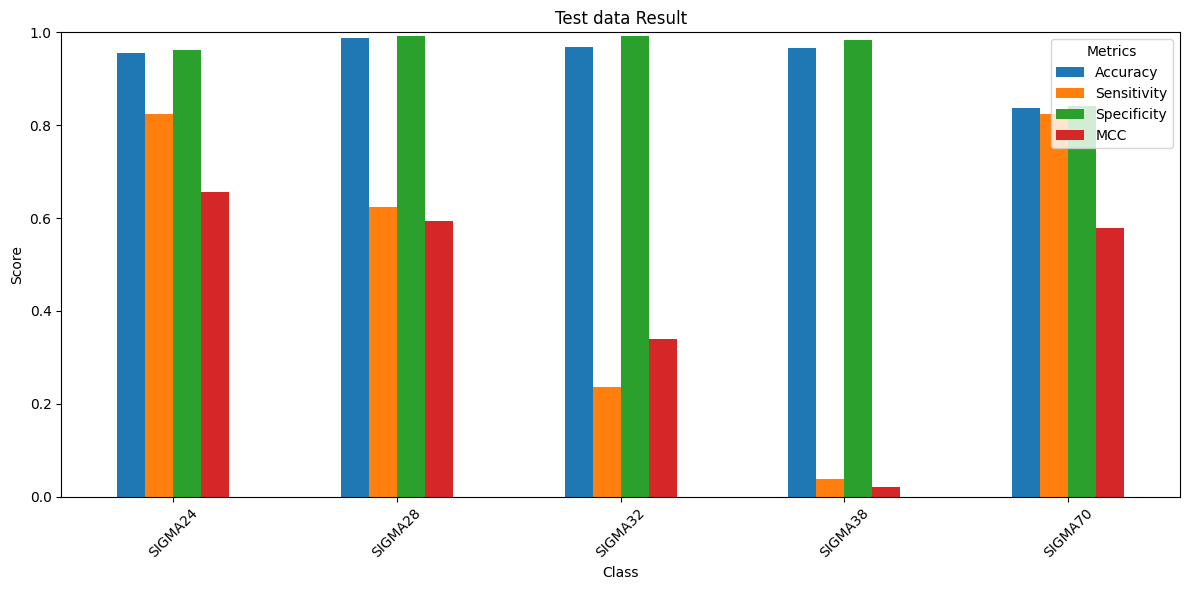

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Create DataFrame
data = {
    "Class": ["SIGMA24", "SIGMA28", "SIGMA32", "SIGMA38", "SIGMA70"],
    "Accuracy": [0.955, 0.988, 0.969, 0.966, 0.838],
    "Sensitivity": [0.825, 0.623, 0.235, 0.037, 0.823],
    "Specificity": [0.962, 0.993, 0.993, 0.983, 0.842],
    "MCC": [0.655, 0.594, 0.339, 0.020, 0.578]
}

df = pd.DataFrame(data)

# Set index
df.set_index("Class", inplace=True)

# Plot
df.plot(kind="bar", figsize=(12, 6))

plt.title("Test data Result")
plt.ylabel("Score")
plt.xlabel("Class")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.legend(title="Metrics")
plt.tight_layout()
plt.show()


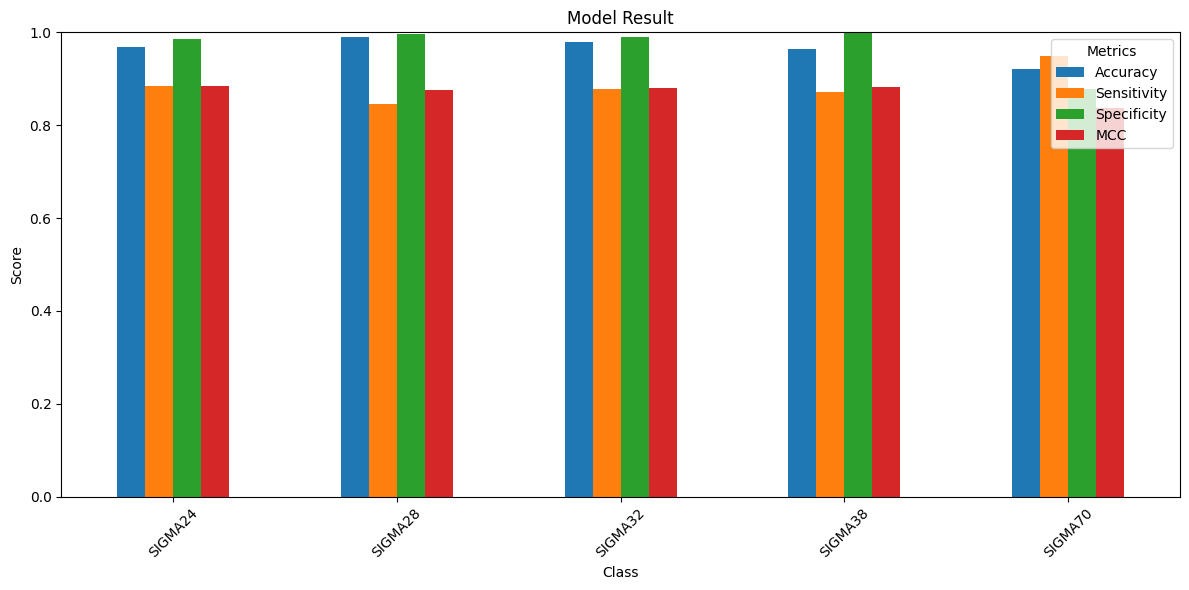

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Create DataFrame
data = {
    "Class": ["SIGMA24", "SIGMA28", "SIGMA32", "SIGMA38", "SIGMA70"],
    "Accuracy": [0.968, 0.989, 0.979, 0.965, 0.921],
    "Sensitivity": [0.885, 0.846, 0.877, 0.872, 0.949],
    "Specificity": [0.985, 0.996, 0.990, 0.9989, 0.879],
    "MCC": [0.885, 0.875, 0.881, 0.882, 0.836]
}

df = pd.DataFrame(data)

# Set index
df.set_index("Class", inplace=True)

# Plot
df.plot(kind="bar", figsize=(12, 6))

plt.title("Model Result")
plt.ylabel("Score")
plt.xlabel("Class")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.legend(title="Metrics")
plt.tight_layout()
plt.show()


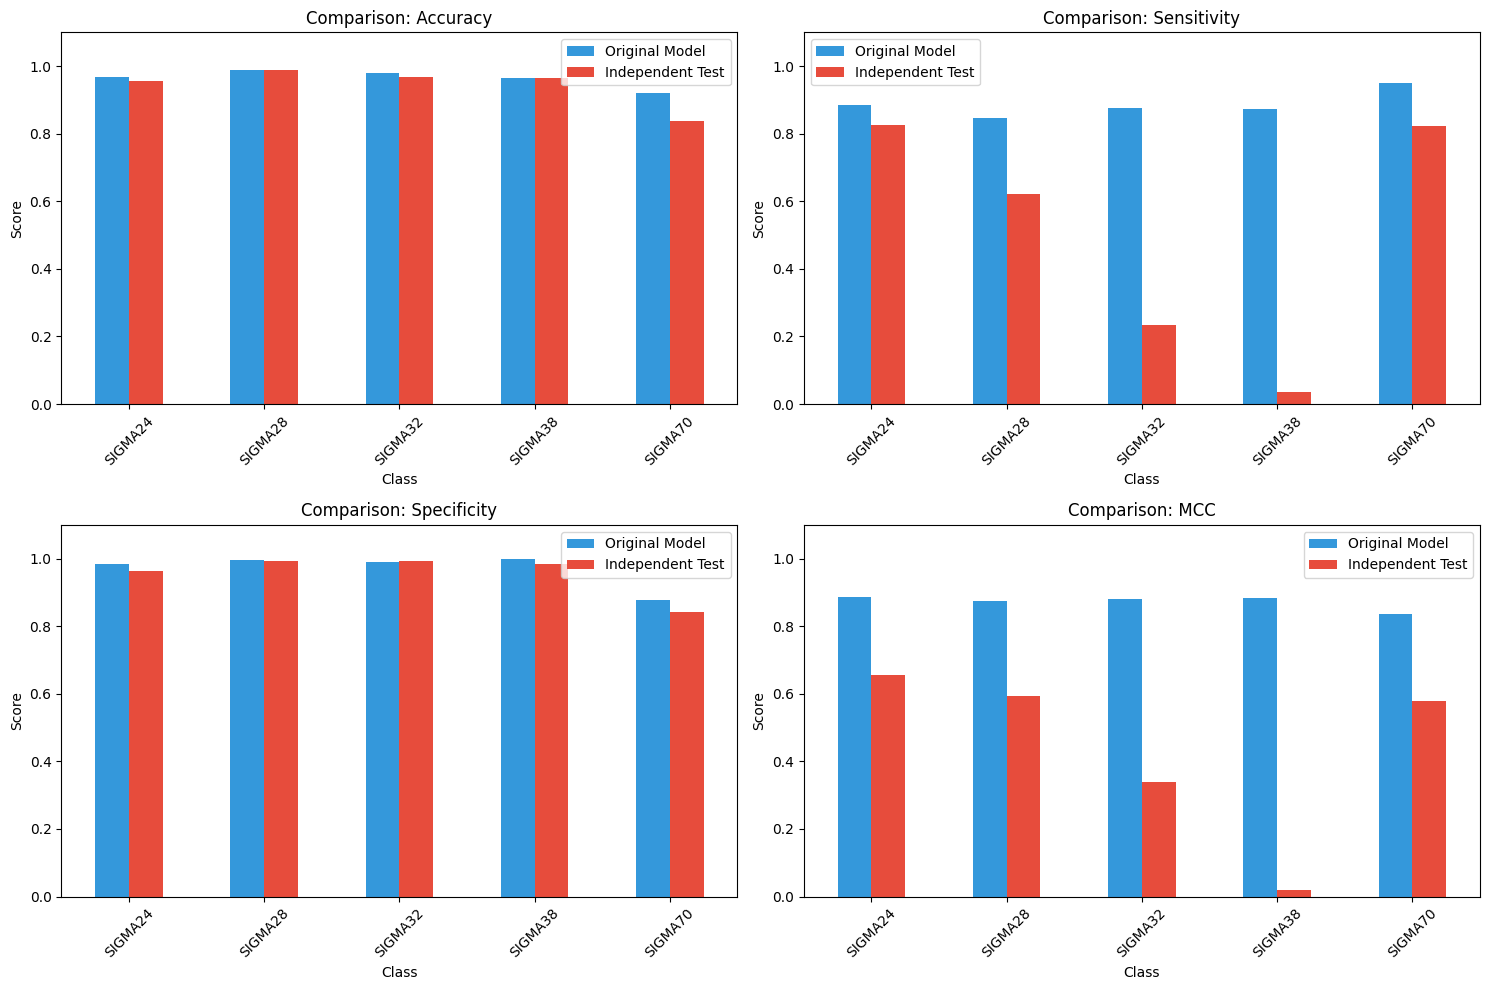

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Data for original Model Results
data_model = {
    "Class": ["SIGMA24", "SIGMA28", "SIGMA32", "SIGMA38", "SIGMA70"],
    "Accuracy": [0.968, 0.989, 0.979, 0.965, 0.921],
    "Sensitivity": [0.885, 0.846, 0.877, 0.872, 0.949],
    "Specificity": [0.985, 0.996, 0.99, 0.9989, 0.879],
    "MCC": [0.885, 0.875, 0.881, 0.882, 0.836]
}

# Data for Independent Test Dataset Results
data_test = {
    "Class": ["SIGMA24", "SIGMA28", "SIGMA32", "SIGMA38", "SIGMA70"],
    "Accuracy": [0.955, 0.988, 0.969, 0.966, 0.838],
    "Sensitivity": [0.825, 0.623, 0.235, 0.037, 0.823],
    "Specificity": [0.962, 0.993, 0.993, 0.983, 0.842],
    "MCC": [0.655, 0.594, 0.339, 0.020, 0.578]
}

df_model = pd.DataFrame(data_model).set_index("Class")
df_test = pd.DataFrame(data_test).set_index("Class")

# Combine dataframes with suffixes
df_combined = df_model.merge(df_test, left_index=True, right_index=True, suffixes=(' (Model)', ' (Test)'))

# Plotting
metrics = ["Accuracy", "Sensitivity", "Specificity", "MCC"]
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 10))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    cols = [f"{metric} (Model)", f"{metric} (Test)"]
    df_combined[cols].plot(kind='bar', ax=axes[i], color=['#3498db', '#e74c3c'])
    axes[i].set_title(f"Comparison: {metric}")
    axes[i].set_ylabel("Score")
    axes[i].set_ylim(0, 1.1)
    axes[i].legend(["Original Model", "Independent Test"])
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

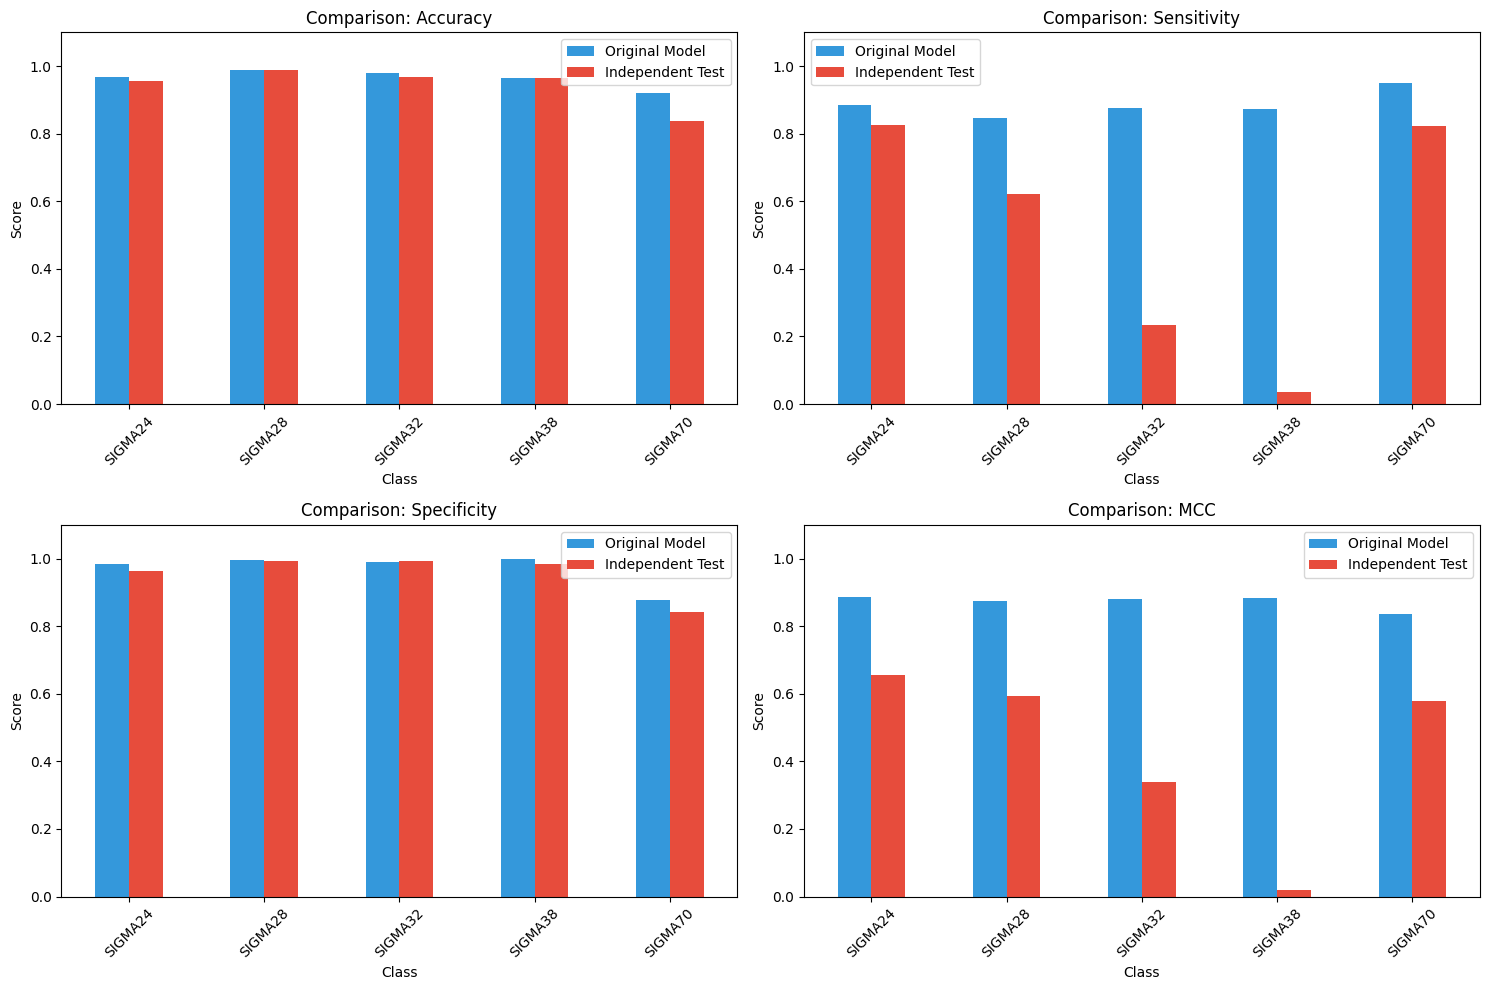

In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Data for original Model Results
data_model = {
    "Class": ["SIGMA24", "SIGMA28", "SIGMA32", "SIGMA38", "SIGMA70"],
    "Accuracy": [0.968, 0.989, 0.979, 0.965, 0.921],
    "Sensitivity": [0.885, 0.846, 0.877, 0.872, 0.949],
    "Specificity": [0.985, 0.996, 0.99, 0.9989, 0.879],
    "MCC": [0.885, 0.875, 0.881, 0.882, 0.836]
}

# Data for Independent Test Dataset Results
data_test = {
    "Class": ["SIGMA24", "SIGMA28", "SIGMA32", "SIGMA38", "SIGMA70"],
    "Accuracy": [0.955, 0.988, 0.969, 0.966, 0.838],
    "Sensitivity": [0.825, 0.623, 0.235, 0.037, 0.823],
    "Specificity": [0.962, 0.993, 0.993, 0.983, 0.842],
    "MCC": [0.655, 0.594, 0.339, 0.020, 0.578]
}

df_model = pd.DataFrame(data_model).set_index("Class")
df_test = pd.DataFrame(data_test).set_index("Class")

# Combine dataframes
df_combined = df_model.merge(df_test, left_index=True, right_index=True, suffixes=(' (Model)', ' (Test)'))

# Plotting
metrics = ["Accuracy", "Sensitivity", "Specificity", "MCC"]
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 10))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    cols = [f"{metric} (Model)", f"{metric} (Test)"]
    df_combined[cols].plot(kind='bar', ax=axes[i], color=['#3498db', '#e74c3c'])
    axes[i].set_title(f"Comparison: {metric}")
    axes[i].set_ylabel("Score")
    axes[i].set_ylim(0, 1.1)
    axes[i].legend(["Original Model", "Independent Test"])
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
# Save the plot as requested
plt.savefig('image.png', dpi=300)
plt.show()